In [ ]:
# For first time setup:

!git clone https://github.com/google/deluca 
%cd deluca

!git checkout improved-api


!pip install -e .


/Users/rsalik/Documents/Code/Google/deluca


/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Obtaining file:///Users/rsalik/Documents/Code/Google/deluca
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for deluca (pyproject.toml) ... done
  Created wheel for deluca: filename=deluca-0.0.17-0.editable-py3-none-any.whl size=8167 sha256=c5475eecb5506bc057dbb4aa431be2215ff411d3779188271c9856347e85d33d
  Stored in directory: /private/var/folders/zd/pxlq94zd389bp96dgw56b0900000gn/T/pip-ephem-wheel-cache-ycn9glmb/wheels/6e/ce/1b/6c4512f4b38168466dee61d1ca5f9765d0c15735eb0d3491c2
Successfully built deluca
^C
Traceback (most recent call last):
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/bin/pip", line 8, in <module>
    sys.exit(main())
             ~~~~^^
  File "/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/pip/_internal/cli/main.py", line 79, in main
    r

In [ ]:
!pip install -q ipympl
# Must restart kernel after this

/Users/rsalik/.pyenv/versions/3.13.1/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [1]:
%matplotlib widget

In [1]:
%load_ext autoreload
%autoreload 1

import jax

from deluca.agents.new.linear import LinearAgent
from deluca.filters.spectral import SpectralFilter
from deluca.memory import MemorySettings
from deluca.agents.new.linear import DefaultSettings as LinearAgentDefaultSettings
from deluca.utils.printing import Task

# JAX random key
rng = jax.random.key(0)

### **Creating an Environment**

In [2]:
%autoreload 1

import jax

from deluca.envs._brax import BraxEnv

# Creating the environment
rng, env_rng = jax.random.split(rng)
env = BraxEnv(env_rng, "inverted_double_pendulum")

/Users/rsalik/.pyenv/versions/3.13.1/envs/deluca-env/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


#### **Defining a loss function**

In [3]:
#@title Loss Function

from jax import Array
from typing import Any
import jax.numpy as jnp
from brax import math


from jax import Array
from typing import Any
import jax.numpy as jnp



def loss_fn(action: Array, next_state: Any, next_obs: Array) -> Array:
    """
    Computes a complex differentiable loss for Brax's inverted_double_pendulum env.
    Encourages upright stability, stillness, center balance, and smoothness.
    
    Args:
        state: brax.physics.base.State (after action applied)
        action: jnp.ndarray of shape [batch_size, action_dim]
        
    Returns:
        scalar loss (batch-mean)
    """

    # Extract physical quantities from Brax's pipeline state
    # Brax's `State` returned by a PipelineEnv has the physics data stored in
    # `pipeline_state`, which itself is a `brax.base.State` containing link-wise
    # transforms (`x`) and motions (`xd`).
    ps = next_state.pipeline_state

    # Unpack key components
    pos = ps.x.pos        # [n_bodies, 3] positions of link frames
    rot = ps.x.rot        # [n_bodies, 4] quaternions of link frames
    vel = ps.xd.vel       # [n_bodies, 3] linear velocities
    ang = ps.xd.ang       # [n_bodies, 3] angular velocities

    # Body indices (based on Brax default)
    cart_idx = 0
    pole1_idx = 1
    pole2_idx = 2

    def get_up_vector(q):
        # Rotate the pole's local +Y axis into the world frame.  If your model's
        # long axis is +Z instead, change the vector to [0., 0., 1.].
        return math.rotate(jnp.array([0.0, 1.0, 0.0]), q)

    pole1_up = get_up_vector(rot[pole1_idx])
    pole2_up = get_up_vector(rot[pole2_idx])

    # We want the up vector to point as close to +Y as possible
    upright_loss = (
        (1.0 - pole1_up[1])**2 + 
        (1.0 - pole2_up[1])**2
    )

    # 2. Pole tip height (encourages vertical pose)
    # Higher tip means more vertical (tip is at pos + rotated pole length)
    pole1_pos = pos[pole1_idx]
    pole2_pos = pos[pole2_idx]

    pole1_height = pole1_pos[1]
    pole2_height = pole2_pos[1]

    height_reward = pole1_height + pole2_height  # want to maximize

    # 3. Angular velocity loss (encourages stability)
    angular_loss = (
        jnp.sum(ang[pole1_idx] ** 2) +
        jnp.sum(ang[pole2_idx] ** 2)
    )

    # 4. Linear velocity loss
    linear_loss = (
        jnp.sum(vel[pole1_idx] ** 2) +
        jnp.sum(vel[pole2_idx] ** 2)
    )

    # 5. Cart position drift
    cart_x_pos = pos[cart_idx][0]
    cart_pos_loss = cart_x_pos ** 2

    # 6. Action magnitude penalty (smoothness)
    action_loss = jnp.sum(action ** 2)

    # Total loss: lower is better
    total_loss = (
        10.0 * upright_loss -
        5.0 * height_reward +
        1.0 * angular_loss +
        0.1 * linear_loss +
        1.0 * cart_pos_loss +
        0.01 * action_loss
    )

    return total_loss



### **Setting up an Agent**
1. Create a memory -- lets the agent store the history of observations and actions, and can add Spectral Filtering
2. Define the agent's settings, or use default
3. Create the agent itself

In [4]:
%autoreload 1

# 1. Create a memory
filter = SpectralFilter(env.observation_size, env.action_size, num_filters=24, spectral_history_length=100)
memory_settings = MemorySettings.from_env(env, 20, filter)

# 2. Define the agent's settings, or use default
# Settings lets us change stuff like optimizer, and model-specific settings like hidden dimension size.
settings = LinearAgentDefaultSettings.replace(loss_fn=loss_fn) # type: ignore

# 3. Create the agent itself
rng, agent_rng = jax.random.split(rng)
agent = LinearAgent(memory_settings, settings, rng=agent_rng)

**Side Note:** You could theoretically include a Normalizer as input to the Agent like so:

```python
from deluca.normalizers.core import DefaultNormalizers

normalizers = DefaultNormalizers()

# Our normalizers will need some data to computer mean and std
# Generate a bunch of random observations and actions to prep our normalizers:


random_agent = SimpleRandom(memory_settings, DefaultSettings, agent_rng)
trajectories = generate_histories(env, agent, memory_settings, 100, 100, rng=rng)

# Important: if we use filtering on the Agent, then we need to generate trajectories with filtering.

normalizers.obs.compute(trajectories[0])
normalizers.action.compute(trajectories[1])






```

#### **Create a Training Loop**

In [5]:
from deluca.utils.printing import progress


losses = []

# Slowly build up the agent's knowledge, first with one step, then working up to multiple steps.
curriculum = [
    (1, 2, 100), # First train for 100 iterations with 1 step averaged over 2 episodes
    (2, 2, 500), # Then train for 500 iterations with 2 steps averaged over 2 episodes
    (3, 3, 500), # ...
    (4, 3, 500),
    (5, 3, 500),
    (6, 3, 500),
    (7, 3, 300),
    (8, 3, 300),
    (10, 5, 1000),
    (15, 7, 5000),
    (30, 7, 5000),
    (50, 7, 15000)
]

for T, N, iters in progress(curriculum, f"Training Agent according to curriculum"):
    rng, train_key = jax.random.split(rng)
    for irng in progress(jax.random.split(train_key, iters), f"Training with {N} episodes of length {T}"):
        losses_out = agent.train(env, N, T, irng)
        losses.append(losses_out)


✔ Training Agent according to curriculum [██████████████████████████████] [Completed 12]


#### **Plotting Results**

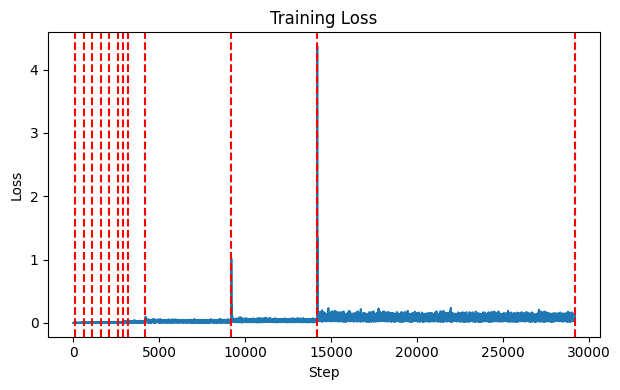

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)

# Plot vertical lines at the end of each training plan
cum_iters = 0
for T, N, iters in curriculum:
    cum_iters += iters
    plt.axvline(x=cum_iters, color='r', linestyle='--')


plt.title('Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


#### **Rendering the trajectory**


**Note:** Only Brax environments support rendering. The process for displaying the render is different in Jupyter notebooks than Python scripts.

In [7]:
%autoreload 1

import jax

from deluca.memory.memory import Memory
from IPython.display import display, HTML

rng, reset_key = jax.random.split(rng)
memory = Memory(memory_settings).reset_env(env, reset_key)

states = [memory.state]
# Run the trained model for 100 steps
for rng in jax.random.split(rng, 100):
    agent_key, env_key = jax.random.split(rng)
    action = agent(memory.get_history(), rng)
    memory = memory.act(env, action, env_key)
    states.append(memory.state)

with open("out.html", "w") as f:
    display(HTML(env.render(states)))
